In [1]:
#@title Install dependencies (first run only)
!pip -q install pycountry openpyxl

import re
import pycountry
import pandas as pd
import numpy as np
from pathlib import Path


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 29.0 MB/s eta 0:00:00


In [2]:
#@title Mount Google Drive and set base paths
from google.colab import drive
drive.mount('/content/drive')

BASE_DIR = Path('/content/drive/MyDrive/ai4trade')
RAW_PATH = BASE_DIR / 'data' / 'raw' / 'exports_2025_chn.xlsx'
OUT_PATH = BASE_DIR / 'data' / 'interim' / 'CHN_exports_2025.parquet'

print(f"Reading from: {RAW_PATH}")
print(f"Will write to: {OUT_PATH}")


Mounted at /content/drive
Reading from: /content/drive/MyDrive/ai4trade/data/raw/exports_2025_chn.xlsx
Will write to: /content/drive/MyDrive/ai4trade/data/interim/CHN_exports_2025.parquet


In [3]:
#@title Utility functions

def clean_hs6(x) -> str:
    """
    Coerce HS6 into a clean 6-char zero-padded string.
    Removes commas, apostrophes, spaces, dots; strips; keeps digits; zfill(6).
    """
    if pd.isna(x):
        return np.nan
    s = str(x)
    s = s.replace(",", "").replace("’", "").replace("'", "").replace(" ", "").replace(".", "")
    s = re.sub(r"[^0-9]", "", s)
    if s == "":
        return np.nan
    return s.zfill(6)[:6]

def derive_hs4(hs6: str) -> str:
    if pd.isna(hs6):
        return np.nan
    return str(hs6)[:4]

def parse_month_header(colname: str):
    """
    Parse common Trademap month headers like:
    'Jan 2025', 'Jan-2025', '2025-01', '2025 Jan', 'January 2025'.
    Returns Timestamp at first day of month or None.
    """
    for fmt in [None, '%b %Y', '%b-%Y', '%Y-%m', '%Y %b', '%B %Y', '%B-%Y']:
        try:
            dt = pd.to_datetime(colname, format=fmt, errors='raise')
            return pd.Timestamp(year=dt.year, month=dt.month, day=1)
        except Exception:
            pass
    return None

def is_iso3(code: str) -> bool:
    try:
        return pycountry.countries.get(alpha_3=code.upper()) is not None
    except Exception:
        return False

def extract_partner_from_sheet(sheet_name: str, prefix="China-") -> str:
    """
    Sheet names are 'China-XXX'. Extract XXX and validate ISO3.
    Handles slight dash/space variations.
    """
    if not sheet_name.startswith(prefix):
        m = re.match(r"China[\s\-–—_]+([A-Za-z]{3})$", sheet_name.strip())
        code = m.group(1).upper() if m else sheet_name.split("-")[-1].strip().upper()
    else:
        code = sheet_name.replace(prefix, "").strip().upper()
    return code


In [4]:
#@title Read Excel (all sheets) and validate partner ISO3 codes
xlsx = pd.read_excel(RAW_PATH, sheet_name=None, header=0, engine='openpyxl')

sheet_partners = {sheet: extract_partner_from_sheet(sheet) for sheet in xlsx.keys()}
invalid = [(sheet, code) for sheet, code in sheet_partners.items() if not is_iso3(code)]

print("Detected sheets and partners:")
for s, c in sheet_partners.items():
    print(f"  {s}  ->  {c} (ISO3={'OK' if is_iso3(c) else 'INVALID'})")

if invalid:
    msg = "Some sheet names don't map to valid ISO3 partners:\n" + \
          "\n".join([f"  - Sheet '{s}' → '{c}' (INVALID)" for s, c in invalid]) + \
          "\n\nPlease rename those sheets to 'China-XXX' with a valid ISO3 code and rerun."
    raise ValueError(msg)


Detected sheets and partners:
  China-USA  ->  USA (ISO3=OK)
  China-HKG  ->  HKG (ISO3=OK)
  China-JPN  ->  JPN (ISO3=OK)
  China-VNM  ->  VNM (ISO3=OK)
  China-KOR  ->  KOR (ISO3=OK)
  China-IND  ->  IND (ISO3=OK)
  China-RUS  ->  RUS (ISO3=OK)
  China-DEU  ->  DEU (ISO3=OK)
  China-NLD  ->  NLD (ISO3=OK)
  China-MYS  ->  MYS (ISO3=OK)
  China-MEX  ->  MEX (ISO3=OK)
  China-THA  ->  THA (ISO3=OK)
  China-SGP  ->  SGP (ISO3=OK)
  China-GBR  ->  GBR (ISO3=OK)
  China-AUS  ->  AUS (ISO3=OK)
  China-TWN  ->  TWN (ISO3=OK)
  China-IDN  ->  IDN (ISO3=OK)
  China-BRA  ->  BRA (ISO3=OK)
  China-ARE  ->  ARE (ISO3=OK)
  China-PHL  ->  PHL (ISO3=OK)
  China-SAU  ->  SAU (ISO3=OK)
  China-CAN  ->  CAN (ISO3=OK)
  China-ITA  ->  ITA (ISO3=OK)
  China-FRA  ->  FRA (ISO3=OK)
  China-ESP  ->  ESP (ISO3=OK)
  China-POL  ->  POL (ISO3=OK)
  China-TUR  ->  TUR (ISO3=OK)
  China-BEL  ->  BEL (ISO3=OK)
  China-KAZ  ->  KAZ (ISO3=OK)
  China-BGD  ->  BGD (ISO3=OK)


In [5]:
#@title Function to normalize a single partner sheet (Exports)
def normalize_partner_sheet(df_raw: pd.DataFrame, partner_iso3: str) -> pd.DataFrame:
    """
    Steps:
      1) Drop 'Total' row if present.
      2) Clean HS6; derive HS4.
      3) Identify month columns and melt to long (Jan–Aug 2025).
      4) Attach identifiers: origin=CHN, destination=partner, trade_flow='Export'.
      5) Drop zeros *after* HS4 derivation (sparsity control).
    """
    df = df_raw.copy()

    # Drop obvious 'Total' rows (often second row)
    first_col = df.columns[0]
    df = df[~df[first_col].astype(str).str.contains(r'^total$', case=False, na=False)]

    # Clean HS6
    df[first_col] = df[first_col].map(clean_hs6)
    df = df[~df[first_col].isna()]

    # Month headers
    month_cols = [c for c in df.columns if c != first_col]
    parsed = {c: parse_month_header(str(c)) for c in month_cols}
    if any(v is None for v in parsed.values()):
        # Fallback to ordered Jan..Aug 2025 assumption
        months = pd.period_range('2025-01', '2025-08', freq='M')
        fallback = {c: pd.Timestamp(m.start_time) for c, m in zip(month_cols, months)}
        for c in month_cols:
            if parsed[c] is None:
                parsed[c] = fallback[c]

    # Reshape
    df_long = df.melt(id_vars=[first_col], value_vars=month_cols,
                      var_name='month_col', value_name='value')
    df_long['month'] = df_long['month_col'].map(parsed)
    df_long.drop(columns=['month_col'], inplace=True)

    # Numerics
    df_long['value'] = pd.to_numeric(df_long['value'], errors='coerce').fillna(0.0)

    # IDs & schema
    df_long = df_long.rename(columns={first_col: 'hs6'})
    df_long['hs4'] = df_long['hs6'].map(derive_hs4)
    df_long['origin'] = 'CHN'
    df_long['destination'] = partner_iso3
    df_long['trade_flow'] = 'Export'

    # Drop zeros after HS4 derivation
    df_long = df_long[df_long['value'] > 0]

    # Final columns & types
    df_long = df_long[['origin', 'destination', 'hs6', 'hs4', 'trade_flow', 'month', 'value']]
    df_long['month'] = pd.to_datetime(df_long['month']).dt.to_period('M').dt.to_timestamp()
    df_long['hs6'] = df_long['hs6'].astype(str)
    df_long['hs4'] = df_long['hs4'].astype(str)

    return df_long


In [6]:
#@title Normalize all partner sheets and concatenate
all_parts = []
for sheet_name, df_raw in xlsx.items():
    partner = sheet_partners[sheet_name]
    part = normalize_partner_sheet(df_raw, partner)
    all_parts.append(part)

df_all = pd.concat(all_parts, axis=0, ignore_index=True)

print("Preview:")
display(df_all.head(10))
print(df_all.dtypes)
print(f"Rows after zero-drop: {len(df_all):,}")


Preview:


,origin,destination,hs6,hs4,trade_flow,month,value
0,CHN,USA,030732,0307,Export,2025-01-01,25000
1,CHN,USA,040891,0408,Export,2025-01-01,65000
2,CHN,USA,130213,1302,Export,2025-01-01,36000
3,CHN,USA,160100,1601,Export,2025-01-01,7000
4,CHN,USA,110813,1108,Export,2025-01-01,32000
5,CHN,USA,250200,2502,Export,2025-01-01,4000
6,CHN,USA,253010,2530,Export,2025-01-01,3000
7,CHN,USA,282630,2826,Export,2025-01-01,33000
8,CHN,USA,281213,2812,Export,2025-01-01,149000
9,CHN,USA,291611,2916,Export,2025-01-01,19000


origin                 object
destination            object
hs6                    object
hs4                    object
trade_flow             object
month          datetime64[ns]
value                   int64
dtype: object
Rows after zero-drop: 745,459


In [7]:
#@title Partner filter: ≥100 unique HS4s (positive) on average per month
mask_2025_jan_aug = (df_all['month'] >= '2025-01-01') & (df_all['month'] <= '2025-08-31')
df_ja = df_all.loc[mask_2025_jan_aug].copy()

monthly_counts = (
    df_ja[df_ja['value'] > 0]
    .groupby(['destination', 'month'])['hs4']
    .nunique()
    .reset_index(name='uniq_hs4')
)

avg_counts = (
    monthly_counts
    .groupby('destination')['uniq_hs4']
    .mean()
    .reset_index(name='avg_monthly_uniq_hs4')
)

eligible_partners = avg_counts.loc[avg_counts['avg_monthly_uniq_hs4'] >= 100, 'destination'].tolist()
print("Eligible partners (avg ≥ 100 HS4s):", eligible_partners)

df_filtered = df_all[df_all['destination'].isin(eligible_partners)].copy()
print(f"Rows after partner filter: {len(df_filtered):,}  (from {len(df_all):,})")


Eligible partners (avg ≥ 100 HS4s): ['ARE', 'AUS', 'BEL', 'BGD', 'BRA', 'CAN', 'DEU', 'ESP', 'FRA', 'GBR', 'HKG', 'IDN', 'IND', 'ITA', 'JPN', 'KAZ', 'KOR', 'MEX', 'MYS', 'NLD', 'PHL', 'POL', 'RUS', 'SAU', 'SGP', 'THA', 'TUR', 'TWN', 'USA', 'VNM']
Rows after partner filter: 745,459  (from 745,459)


In [8]:
#@title Sanity checks
assert set(df_filtered.columns) == {'origin','destination','hs6','hs4','trade_flow','month','value'}

# Only China exports in 2025 Jan..Aug
assert (df_filtered['origin'] == 'CHN').all()
assert (df_filtered['trade_flow'] == 'Export').all()
assert df_filtered['month'].min() >= pd.Timestamp('2025-01-01')
assert df_filtered['month'].max() <= pd.Timestamp('2025-08-31')

# HS code sanity
assert df_filtered['hs6'].str.len().eq(6).all()
assert df_filtered['hs4'].str.len().eq(4).all()

print("All checks passed.")


All checks passed.


In [9]:
#@title Write parquet to ai4trade/data/interim
OUT_PATH.parent.mkdir(parents=True, exist_ok=True)
df_filtered.to_parquet(OUT_PATH, index=False)
print(f"Saved: {OUT_PATH}")


Saved: /content/drive/MyDrive/ai4trade/data/interim/CHN_exports_2025.parquet


In [10]:
# Calculate the first and last month of exports for each partner
monthly_export_range = (
    df_filtered.groupby('destination')['month']
    .agg(['min', 'max'])
    .reset_index()
)

# Rename columns for clarity
monthly_export_range.columns = ['Partner', 'First Export Month', 'Last Export Month']

# Print the result
print("First and Last Export Month for Each Partner:")
display(monthly_export_range)

First and Last Export Month for Each Partner:


,Partner,First Export Month,Last Export Month
0,ARE,2025-01-01,2025-08-01
1,AUS,2025-01-01,2025-08-01
2,BEL,2025-01-01,2025-08-01
3,BGD,2025-01-01,2025-08-01
4,BRA,2025-01-01,2025-08-01
5,CAN,2025-01-01,2025-08-01
6,DEU,2025-01-01,2025-08-01
7,ESP,2025-01-01,2025-08-01
8,FRA,2025-01-01,2025-08-01
9,GBR,2025-01-01,2025-08-01


In [12]:
# Filter for the month of August 2025
august_exports = df_filtered[df_filtered['month'] == '2025-08-01'].copy()

# Group by destination and sum the value
august_export_summary = august_exports.groupby('destination')['value'].sum().reset_index()

# Rename columns for clarity
august_export_summary.columns = ['Partner', 'Total Export Value (August 2025)']

# Sort in descending order by total export value
august_export_summary = august_export_summary.sort_values(by='Total Export Value (August 2025)', ascending=False)

# Print the result
print("Total Export Value for Each Partner in August 2025 (Descending Order):")
display(august_export_summary)

Total Export Value for Each Partner in August 2025 (Descending Order):


,Partner,Total Export Value (August 2025)
28,USA,31658572000
10,HKG,26939648000
29,VNM,17594760000
14,JPN,12773565000
12,IND,12422893000
16,KOR,11586668000
6,DEU,10668840000
22,RUS,8526834000
19,NLD,8523461000
18,MYS,8518752000


# Task
Plot total export value in billion of USD on y axis and months on X axis for top 10 partners from China.

## Identify top 10 partners

### Subtask:
Get the list of top 10 partners based on the August 2025 total export value from the `august_export_summary` DataFrame.


**Reasoning**:
Extract the top 10 partners from the `august_export_summary` DataFrame and store them in a list.



In [14]:
top_10_partners = august_export_summary['Partner'].head(10).tolist()
print("Top 10 partners based on August 2025 export value:", top_10_partners)

Top 10 partners based on August 2025 export value: ['USA', 'HKG', 'VNM', 'JPN', 'IND', 'KOR', 'DEU', 'RUS', 'NLD', 'MYS']


## Filter data

### Subtask:
Filter the `df_filtered` DataFrame to include only the data for the top 10 partners.


**Reasoning**:
Filter the dataframe to include only the top 10 partners and display the head and shape.



In [15]:
df_top_10 = df_filtered[df_filtered['destination'].isin(top_10_partners)].copy()
print("Preview of df_top_10:")
display(df_top_10.head())
print(f"Shape of df_top_10: {df_top_10.shape}")

Preview of df_top_10:


,origin,destination,hs6,hs4,trade_flow,month,value
0,CHN,USA,030732,0307,Export,2025-01-01,25000
1,CHN,USA,040891,0408,Export,2025-01-01,65000
2,CHN,USA,130213,1302,Export,2025-01-01,36000
3,CHN,USA,160100,1601,Export,2025-01-01,7000
4,CHN,USA,110813,1108,Export,2025-01-01,32000


Shape of df_top_10: (274605, 7)


## Aggregate monthly export value

### Subtask:
Group the filtered data by month and partner and sum the export values.


**Reasoning**:
Group the filtered data by month and partner and sum the export values as requested.



In [16]:
# Group by month and destination and sum the value
monthly_export_value = df_top_10.groupby(['month', 'destination'])['value'].sum().reset_index()

# Print the result
print("Monthly Export Value for Top 10 Partners:")
display(monthly_export_value.head())

Monthly Export Value for Top 10 Partners:


,month,destination,value
0,2025-01-01,DEU,10256735000
1,2025-01-01,HKG,21425925000
2,2025-01-01,IND,12306892000
3,2025-01-01,JPN,14347731000
4,2025-01-01,KOR,11715952000


## Prepare data for plotting

### Subtask:
Convert the export values to billions of USD.


**Reasoning**:
Divide the 'value' column by 1,000,000,000 to convert the values to billions of USD and display the head of the updated dataframe.



In [17]:
monthly_export_value['value_billions'] = monthly_export_value['value'] / 1_000_000_000
print("Monthly Export Value for Top 10 Partners in Billions (Preview):")
display(monthly_export_value.head())

Monthly Export Value for Top 10 Partners in Billions (Preview):


,month,destination,value,value_billions
0,2025-01-01,DEU,10256735000,10.256735
1,2025-01-01,HKG,21425925000,21.425925
2,2025-01-01,IND,12306892000,12.306892
3,2025-01-01,JPN,14347731000,14.347731
4,2025-01-01,KOR,11715952000,11.715952


## Visualize export trends

### Subtask:
Create a line plot showing the total export value for each of the top 10 partners over the months.


**Reasoning**:
Create a line plot to visualize the monthly export value for the top 10 partners.



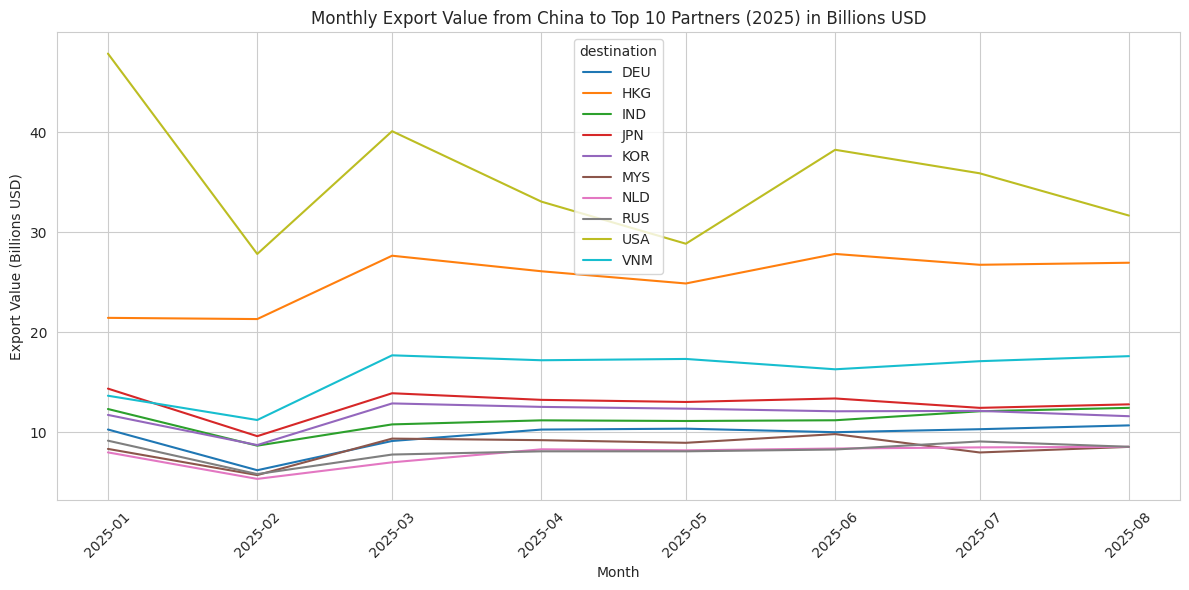

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

plt.figure(figsize=(12, 6))
sns.lineplot(data=monthly_export_value, x='month', y='value_billions', hue='destination')

plt.title("Monthly Export Value from China to Top 10 Partners (2025) in Billions USD")
plt.xlabel("Month")
plt.ylabel("Export Value (Billions USD)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Summary:

### Data Analysis Key Findings

*   The top 10 partners for China based on August 2025 export value are USA, HKG, VNM, JPN, IND, KOR, DEU, RUS, NLD, and MYS.
*   The data was filtered to include only these top 10 partners, resulting in a DataFrame with 274,605 rows.
*   Monthly export values for each of the top 10 partners were aggregated.
*   These monthly export values were converted to billions of USD for visualization.

### Insights or Next Steps

*   Analyze the monthly trends for each partner to identify seasonality or significant changes in export value.
*   Investigate the specific goods being exported to the partners with the highest export values.
